# CIFAR-10 dataset

In [9]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import normalize

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## 1. Loading and observing data

In [4]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Check number of samples
print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

# Check image and label shapes
print(f"Training image shape: {x_train.shape[1:]}")
print(f"Test image shape: {x_test.shape[1:]}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

Training samples: 50000
Test samples: 10000
Training image shape: (32, 32, 3)
Test image shape: (32, 32, 3)
Training labels shape: (50000, 1)
Test labels shape: (10000, 1)


### Data visualization


/tmp/ipykernel_300448/1799962141.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[idx])


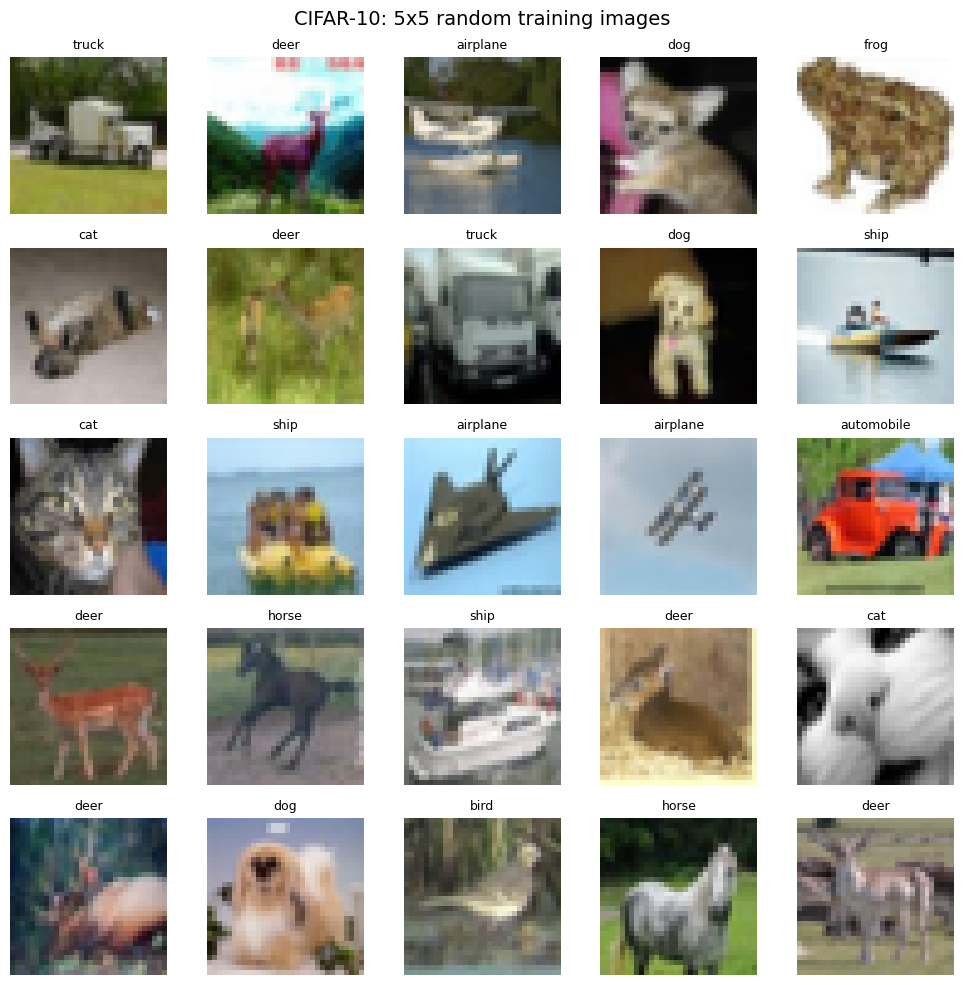

In [8]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# 5x5 completely random images
n_rows, n_cols = 5, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
random_indices = np.random.choice(len(x_train), n_rows * n_cols, replace=False)

for ax, idx in zip(axes.flat, random_indices):
    label = int(y_train[idx])
    ax.imshow(x_train[idx])
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")

plt.suptitle("CIFAR-10: 5x5 random training images", fontsize=14)
plt.tight_layout()
plt.show()


### Normalize the data

In [12]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Per-channel normalization (compute on training set only)
channel_mean = x_train.mean(axis=(0, 1, 2), keepdims=True)
channel_std = x_train.std(axis=(0, 1, 2), keepdims=True)

x_train = (x_train - channel_mean) / (channel_std + 1e-7)
x_test = (x_test - channel_mean) / (channel_std + 1e-7)

print("Channel mean:", channel_mean.reshape(-1))
print("Channel std:", channel_std.reshape(-1))


Channel mean: [0.00192707 0.00189082 0.0017511 ]
Channel std: [0.00096875 0.00095484 0.00102584]


### Transform labels into "one-hot" vectors

In [13]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

## 2. Convolutional Neural Network

### Build this network using Keras

In [14]:
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)

# we fill the input image to keep its size after the convolution
padding = 'same'

# specify stride size
stride = 1

# specify filter size (or kernel): (3,3) means 3x3
kernel_size = (3,3)

# specify filter numbers
filters = 8

# specify ReLU activation function
activation = 'relu'

# create the 2D convolutional layer by specifying its hyper-parameters and link it to the input layer
hidden_conv_layer_1 = tf.keras.layers.Conv2D(filters=filters,
                                          kernel_size=kernel_size,strides=stride,
                                          padding=padding,activation=activation)(input_layer)


# specify pooling size: (2,2) means 2x2
pool_size = (2,2)

# specify stride
stride = 2

# specify padding
padding = 'valid'

# create the Max Pooling operation for 2D (for images it's often 2D)
pooling_conv_layer_1 = tf.keras.layers.MaxPooling2D(pool_size = pool_size, strides = stride,
                                          padding=padding)(hidden_conv_layer_1)

# we transform the output of the pooling (which is an image) into a vector
flattened_layer_1 = tf.keras.layers.Flatten()(pooling_conv_layer_1)


nb_classes = y_train.shape[1]
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(flattened_layer_1)

I0000 00:00:1772725460.366943  300448 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:09:00.0, compute capability: 8.6


### Prepare and compile your model with the Adam optimizer

In [15]:
model_cnn = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
model_cnn.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,714 (80.91 KB)

 Trainable params: 20,714 (80.91 KB)

 Non-trainable params: 0 (0.00 B)